## Parte 1

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

batch_size = 64

# Configuração do dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# O conjunto de dados possui imagens PILImage no intervalo [0, 1].
# Transformamos em Tensores com intervalo normalizado [-1, 1]
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# CIFAR10: 60000 imagens coloridas 32x32 em 10 classes, com 6000 imagens por classe
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

# Data loader
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('avião', 'carro', 'pássaro', 'gato',
           'veado', 'cachorro', 'sapo', 'cavalo', 'navio', 'caminhão')

100%|██████████| 170M/170M [00:03<00:00, 48.8MB/s]


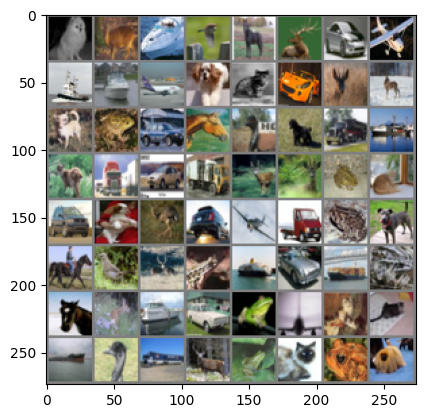

In [2]:
def imshow(img):
    img = img / 2 + 0.5  # desnormalizar
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# obtenha algumas imagens aleatórias de treinamento
dataiter = iter(train_loader)
images, labels = dataiter.__next__()

# exibir imagens
imshow(torchvision.utils.make_grid(images))

In [3]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # -> n, 6, 14, 14
        x = self.pool(F.relu(self.conv2(x)))  # -> n, 16, 5, 5
        x = x.view(-1, 16 * 5 * 5)            # -> n, 400
        x = F.relu(self.fc1(x))               # -> n, 120
        x = F.relu(self.fc2(x))               # -> n, 84
        x = self.fc3(x)                       # -> n, 10
        return x

# Hiperparâmetros
num_epochs = 10
learning_rate = 0.001

model = ConvNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

n_total_steps = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Passo à frente
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Retropropagação e otimização
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print (f'Época [{epoch+1}/{num_epochs}], Passo [{i+1}/{n_total_steps}], Perda: {loss.item():.4f}')

print('Treinamento concluído')
PATH = './cnn.pth'
torch.save(model.state_dict(), PATH)


Época [1/10], Passo [100/782], Perda: 2.2945
Época [1/10], Passo [200/782], Perda: 1.7652
Época [1/10], Passo [300/782], Perda: 1.6651
Época [1/10], Passo [400/782], Perda: 1.4833
Época [1/10], Passo [500/782], Perda: 1.5758
Época [1/10], Passo [600/782], Perda: 1.4937
Época [1/10], Passo [700/782], Perda: 1.4524
Época [2/10], Passo [100/782], Perda: 1.4001
Época [2/10], Passo [200/782], Perda: 1.1339
Época [2/10], Passo [300/782], Perda: 1.3192
Época [2/10], Passo [400/782], Perda: 1.3349
Época [2/10], Passo [500/782], Perda: 1.3090
Época [2/10], Passo [600/782], Perda: 1.2300
Época [2/10], Passo [700/782], Perda: 1.0562
Época [3/10], Passo [100/782], Perda: 1.2453
Época [3/10], Passo [200/782], Perda: 1.1935
Época [3/10], Passo [300/782], Perda: 1.1580
Época [3/10], Passo [400/782], Perda: 1.1512
Época [3/10], Passo [500/782], Perda: 1.1368
Época [3/10], Passo [600/782], Perda: 1.3525
Época [3/10], Passo [700/782], Perda: 0.9363
Época [4/10], Passo [100/782], Perda: 1.2103
Época [4/1

In [4]:
# Testando o modelo
with torch.no_grad():
    n_correct = 0
    n_samples = 0
    n_class_correct = [0 for i in range(10)]
    n_class_samples = [0 for i in range(10)]
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        # max retorna (valor, índice)
        _, predicted = torch.max(outputs, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()

        for i in range(labels.size(0)):
            label = labels[i]
            pred = predicted[i]
            if (label == pred):
                n_class_correct[label] += 1
            n_class_samples[label] += 1

    acc = 100.0 * n_correct / n_samples
    print(f'Acurácia da rede: {acc} %')

    for i in range(10):
        acc = 100.0 * n_class_correct[i] / n_class_samples[i]
        print(f'Acurácia de {classes[i]}: {acc} %')


Acurácia da rede: 63.63 %
Acurácia de avião: 66.3 %
Acurácia de carro: 78.2 %
Acurácia de pássaro: 40.3 %
Acurácia de gato: 58.4 %
Acurácia de veado: 62.4 %
Acurácia de cachorro: 43.8 %
Acurácia de sapo: 73.9 %
Acurácia de cavalo: 70.6 %
Acurácia de navio: 68.3 %
Acurácia de caminhão: 74.1 %


## Parte 2

In [ ]:
!pip install facenet-pytorch

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
import torchvision.transforms.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

plt.rcParams['savefig.bbox'] = 'tight'


In [3]:
def show(imgs, mean=(0,0,0), std=(1,1,1)):
    if not isinstance(imgs, list):
        imgs = [imgs]

    # Remover a normalização
    for t, m, s in zip(imgs, mean, std):
            t.mul_(s).add_(m)

    fix, axs = plt.subplots(ncols=len(imgs), squeeze=False, figsize=(10,10))
    for i, img in enumerate(imgs):
        img = img.detach()
        img = img.permute(1, 2, 0)
        axs[0, i].imshow(img)
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

def get_mean_and_std(dataloader):
    channels_sum, channels_squared_sum, num_batches = 0, 0, 0
    for data, _ in dataloader:
        # Calcula a média para batch, altura e largura. Não para os canais
        # imagem -> [batch_size x 3 x image_size x image_size]
        channels_sum += torch.mean(data, dim=[0,2,3])
        channels_squared_sum += torch.mean(data**2, dim=[0,2,3])
        num_batches += 1

    mean = channels_sum / num_batches

    # std = sqrt(E[X^2] - (E[X])^2)
    std = (channels_squared_sum / num_batches - mean ** 2) ** 0.5

    # Converte para tupla para compatibilidade
    mean = tuple(mean.numpy())
    std = tuple(std.numpy())

    return mean, std

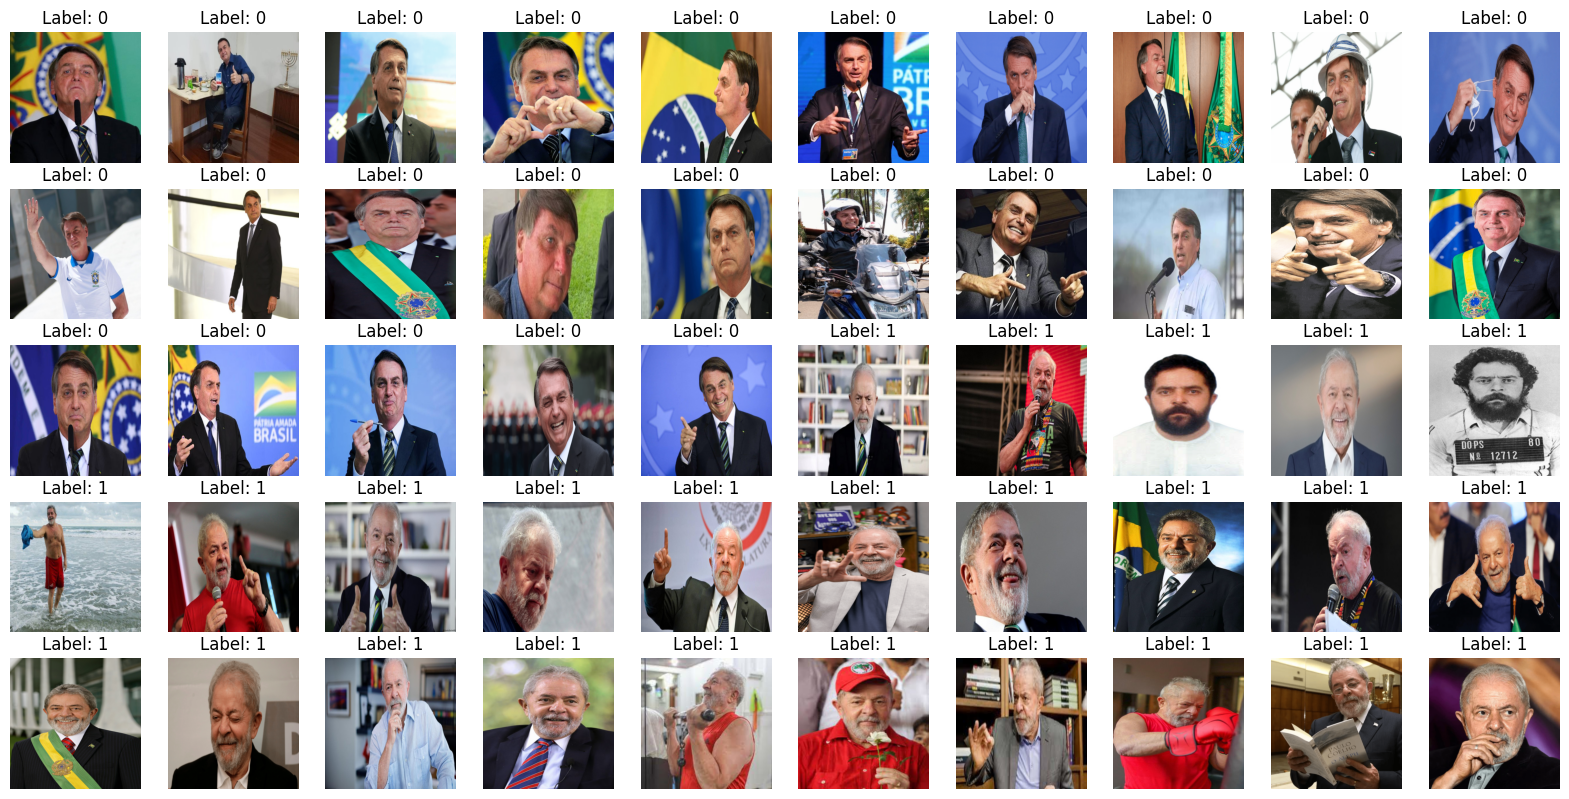

In [4]:
data_dir = '/content/drive/MyDrive/data/bolsolula/train'

dataset = datasets.ImageFolder(data_dir, transform=transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
]))

loader = DataLoader(
    dataset,
    num_workers=2,
    batch_size=32
)

# Create a figure for plotting
plt.figure(figsize=(20,20))

img_counter = 0
for i, (images, labels) in enumerate(loader):
    for j in range(images.shape[0]):  # Loop through each image in the batch
        img_counter += 1
        # Transform the image tensor (C, H, W) to (H, W, C) for displaying
        npimg = images[j].numpy().transpose((1, 2, 0))
        # If images are grayscale, convert to 3 channels
        if npimg.shape[2] == 1:
            npimg = np.repeat(npimg, 3, axis=2)
        plt.subplot(10, 10, img_counter)  # Assume you want to plot 100 images in a 10 by 10 grid
        plt.imshow(npimg)
        plt.title(f"Label: {labels[j].item()}")
        plt.axis('off')
        if img_counter == 100:  # Stop after 100 images
            break
    if img_counter == 100:
        break

plt.show()

In [5]:
path = '/content/drive/MyDrive/data/bolsolula/train'

transform = transforms.Compose([transforms.Resize((224,224)),
                                transforms.ToTensor()])

dataset = datasets.ImageFolder(path, transform=transform)

dataloader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)

mean, std = get_mean_and_std(dataloader)

print(f'Média: {mean}')
print(f'Desvio-padrão: {std}')

Média: (0.47339207, 0.44152728, 0.4483808)
Desvio-padrão: (0.2990234, 0.2826803, 0.29734504)


In [6]:
path = '/content/drive/MyDrive/data/bolsolula/train'

transform = transforms.Compose([#transforms.Resize((224,224)),
                                transforms.RandomResizedCrop((224,224)),
                                transforms.RandomRotation(30),
                                transforms.RandomHorizontalFlip(),
                                transforms.ToTensor(),
                                transforms.Normalize(mean,std)
                                ])

train_dataset = datasets.ImageFolder(path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

bolsonaro 13
lula 19


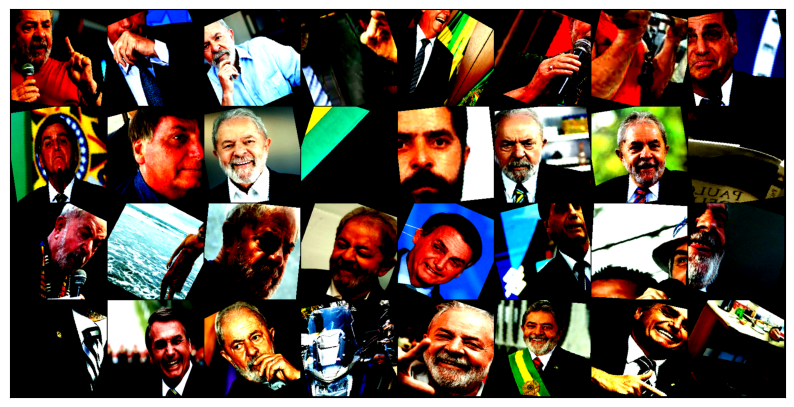

In [8]:
images, labels = next(iter(train_loader))
grid = torchvision.utils.make_grid(images)

#show(grid, mean=mean, std=std)
show(grid)


print(dataset.classes[0], len(labels[labels==0]))
print(dataset.classes[1], len(labels[labels==1]))

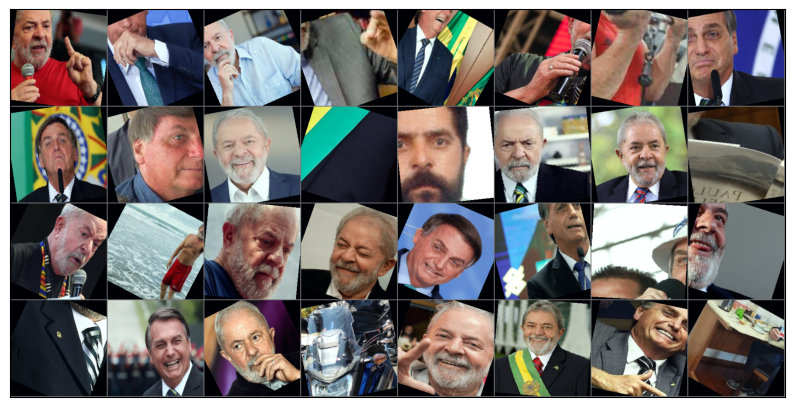

In [9]:
# Desnormalizar
show(grid, mean=mean, std=std)

In [10]:
path = '/content/drive/MyDrive/data/bolsolula/val'

transform = transforms.Compose([transforms.Resize((224,224)),
                                transforms.ToTensor(),
                                transforms.Normalize(mean,std)])

val_dataset = datasets.ImageFolder(path, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=len(dataset), shuffle=False)
train_loader2 = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)

bolsonaro 25
lula 25


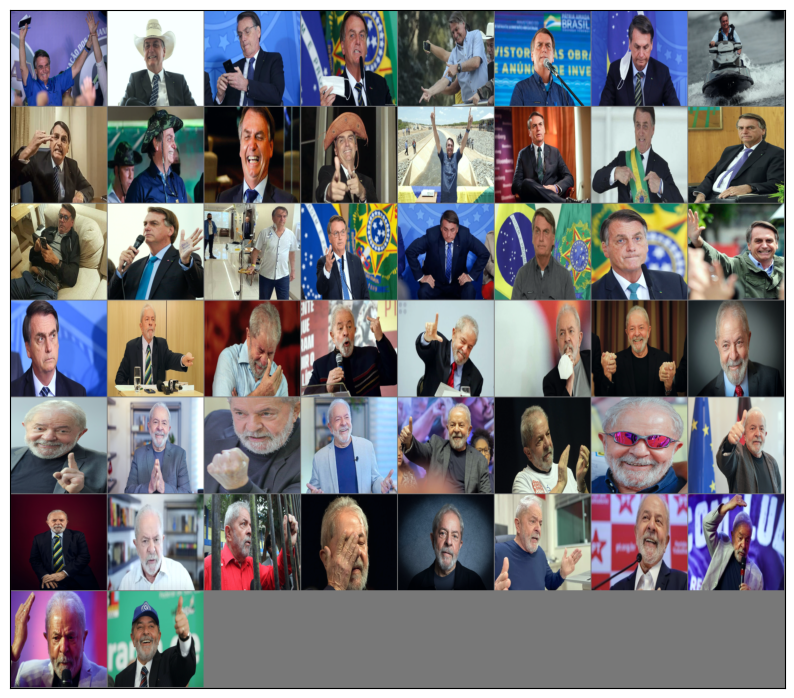

In [11]:
images, labels = next(iter(val_loader))
grid = torchvision.utils.make_grid(images)

show(grid, mean=mean, std=std)

print(dataset.classes[0], len(labels[labels==0]))
print(dataset.classes[1], len(labels[labels==1]))

In [12]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

model = models.resnet18(pretrained=False) #pesos aleatórios
model

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [15]:
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

In [17]:
num_epochs=100
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.001)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Loop de treinamento
for epoch in range(num_epochs):
    for i, data in enumerate(train_loader):
        # obter as entradas
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)

        # Propagação para frente
        y_pred = model(inputs)

        # Calcular e imprimir o loss
        loss = criterion(y_pred, labels)

        # Backpropagation e atualização dos pesos
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    scheduler.step() # Ajusta o learning rate conforme agendamento

    with torch.no_grad():
        X_train,y_train = next(iter(train_loader2))

        y_pred = model(X_train.to(device))
        loss_train = criterion(y_pred, y_train.to(device))

        y_true = y_train.numpy()
        y_pred = np.asarray([np.argmax(x) for x in y_pred.cpu().numpy()])

        acc_train = accuracy_score(y_true, y_pred)
        f1_train = f1_score(y_true, y_pred, average=None)
        f1_train_avg = f1_score(y_true, y_pred, average='weighted')

        ######################################################################

        X_test,y_test = next(iter(val_loader))

        y_pred = model(X_test.to(device))
        loss_test = criterion(y_pred, y_test.to(device))

        y_true = y_test.numpy()
        y_pred = np.asarray([np.argmax(x) for x in y_pred.cpu().numpy()])

        acc_test = accuracy_score(y_true, y_pred)
        f1_test = f1_score(y_true, y_pred, average=None)
        f1_test_avg = f1_score(y_true, y_pred, average='weighted')

        #print(f'Epoch {epoch + 1} | lr: {scheduler.get_last_lr()[0]:.2e} | Loss (train): {loss_train:.4f} | Loss (test): {loss_test:.4f} | accuracy (train): {100*acc_train:.2f}% | accuracy (test): {100*acc_test:.2f}%')
        print(f'Epoch {epoch + 1} | lr: {scheduler.get_last_lr()[0]:.2e} | Loss (train): {loss_train:.4f} | Loss (test): {loss_test:.4f} | f1-avg (train): {100*f1_train_avg:.2f}% | f1-avg (test): {100*f1_test_avg:.2f}%')

        print(150*'*')
        df = pd.DataFrame({'Classe': [nome for nome in val_dataset.classes],
                            '%treino': 100*f1_train,
                            '%teste': 100*f1_test})
        print(df.set_index('Classe'))
        print(150*'*')

        if (epoch+1)==1:
            loss_test_best = loss_test

        if loss_test < loss_test_best:
            print('Salvando o modelo!')
            print(150*'*')
            torch.save(model.state_dict(), 'projeto.pt')
            loss_test_best = loss_test

Epoch 1 | lr: 1.00e-03 | Loss (train): 0.7628 | Loss (test): 0.7539 | f1-avg (train): 33.33% | f1-avg (test): 33.33%
******************************************************************************************************************************************************
             %treino     %teste
Classe                         
bolsonaro  66.666667  66.666667
lula        0.000000   0.000000
******************************************************************************************************************************************************
Epoch 2 | lr: 1.00e-03 | Loss (train): 0.7180 | Loss (test): 0.7272 | f1-avg (train): 33.33% | f1-avg (test): 33.33%
******************************************************************************************************************************************************
             %treino     %teste
Classe                         
bolsonaro  66.666667  66.666667
lula        0.000000   0.000000
*********************************************************

KeyboardInterrupt: 

In [18]:
from facenet_pytorch import InceptionResnetV1

model = InceptionResnetV1(pretrained='vggface2', device=device, classify=True, num_classes=2)
model = model.to(device)

num_epochs=25
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Loop de treinamento
for epoch in range(num_epochs):
    for i, data in enumerate(train_loader):
        # obter as entradas
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)

        # Propagação para frente
        y_pred = model(inputs)

        # Calcular e imprimir o loss
        loss = criterion(y_pred, labels)

        # Backpropagation e atualização dos pesos
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    scheduler.step() # Ajusta o learning rate conforme agendamento

    with torch.no_grad():
        X_train,y_train = next(iter(train_loader2))

        y_pred = model(X_train.to(device))
        loss_train = criterion(y_pred, y_train.to(device))

        y_true = y_train.numpy()
        y_pred = np.asarray([np.argmax(x) for x in y_pred.cpu().numpy()])

        acc_train = accuracy_score(y_true, y_pred)
        f1_train = f1_score(y_true, y_pred, average=None)
        f1_train_avg = f1_score(y_true, y_pred, average='weighted')

        ######################################################################

        X_test,y_test = next(iter(val_loader))

        y_pred = model(X_test.to(device))
        loss_test = criterion(y_pred, y_test.to(device))

        y_true = y_test.numpy()
        y_pred = np.asarray([np.argmax(x) for x in y_pred.cpu().numpy()])

        acc_test = accuracy_score(y_true, y_pred)
        f1_test = f1_score(y_true, y_pred, average=None)
        f1_test_avg = f1_score(y_true, y_pred, average='weighted')

        #print(f'Epoch {epoch + 1} | lr: {scheduler.get_last_lr()[0]:.2e} | Loss (train): {loss_train:.4f} | Loss (test): {loss_test:.4f} | accuracy (train): {100*acc_train:.2f}% | accuracy (test): {100*acc_test:.2f}%')
        print(f'Epoch {epoch + 1} | lr: {scheduler.get_last_lr()[0]:.2e} | Loss (train): {loss_train:.4f} | Loss (test): {loss_test:.4f} | f1-avg (train): {100*f1_train_avg:.2f}% | f1-avg (test): {100*f1_test_avg:.2f}%')

        print(150*'*')
        df = pd.DataFrame({'Classe': [nome for nome in val_dataset.classes],
                            '%treino': 100*f1_train,
                            '%teste': 100*f1_test})
        print(df.set_index('Classe'))
        print(150*'*')

        if (epoch+1)==1:
            loss_test_best = loss_test

        if loss_test < loss_test_best:
            print('Salvando o modelo!')
            print(150*'*')
            torch.save(model.state_dict(), 'projeto.pt')
            loss_test_best = loss_test

  0%|          | 0.00/107M [00:00<?, ?B/s]

Epoch 1 | lr: 1.00e-03 | Loss (train): 0.6657 | Loss (test): 0.7786 | f1-avg (train): 60.00% | f1-avg (test): 51.92%
******************************************************************************************************************************************************
           %treino     %teste
Classe                       
bolsonaro     60.0  50.000000
lula          60.0  53.846154
******************************************************************************************************************************************************
Epoch 2 | lr: 1.00e-03 | Loss (train): 0.5118 | Loss (test): 0.7313 | f1-avg (train): 71.96% | f1-avg (test): 56.00%
******************************************************************************************************************************************************
             %treino  %teste
Classe                      
bolsonaro  70.833333    56.0
lula       73.076923    56.0
*****************************************************************************

## Parte 3

In [ ]:
!pip install facenet-pytorch

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
import torchvision.transforms.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

import facenet_pytorch
from facenet_pytorch import MTCNN, InceptionResnetV1
from facenet_pytorch import MTCNN, InceptionResnetV1, fixed_image_standardization, training

plt.rcParams['savefig.bbox'] = 'tight'

In [22]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [25]:
def show(imgs, mean=(0,0,0), std=(1,1,1)):
    if not isinstance(imgs, list):
        imgs = [imgs]

    # Remover a normalização
    for t, m, s in zip(imgs, mean, std):
            t.mul_(s).add_(m)

    fix, axs = plt.subplots(ncols=len(imgs), squeeze=False, figsize=(10,10))
    for i, img in enumerate(imgs):
        img = img.detach()
        img = img.permute(1, 2, 0)
        axs[0, i].imshow(img)
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

def get_mean_and_std(dataloader):
    channels_sum, channels_squared_sum, num_batches = 0, 0, 0
    for data, _ in dataloader:
        # Calcula a média para batch, altura e largura. Não para os canais
        # imagem -> [batch_size x 3 x image_size x image_size]
        channels_sum += torch.mean(data, dim=[0,2,3])
        channels_squared_sum += torch.mean(data**2, dim=[0,2,3])
        num_batches += 1

    mean = channels_sum / num_batches

    # std = sqrt(E[X^2] - (E[X])^2)
    std = (channels_squared_sum / num_batches - mean ** 2) ** 0.5

    # Converte para tupla para compatibilidade
    mean = tuple(mean.numpy())
    std = tuple(std.numpy())

    return mean, std

In [26]:
mtcnn = MTCNN(
    image_size=160, margin=0, min_face_size=20,
    thresholds=[0.6, 0.7, 0.7], factor=0.709, post_process=True,
    device=device
)

In [29]:
path = '/content/drive/MyDrive/data/bolsolula/train_cropped'

transform = transforms.Compose([transforms.Resize((160,160)),
                                transforms.ToTensor()])

dataset = datasets.ImageFolder(path, transform=transform)

dataloader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)

mean, std = get_mean_and_std(dataloader)

print(f'Média: {mean}')
print(f'Desvio-padrão: {std}')

Média: (0.63650453, 0.46323204, 0.4128564)
Desvio-padrão: (0.20881261, 0.17987143, 0.1780428)


In [30]:
data_dir = '/content/drive/MyDrive/data/bolsolula/val'

dataset = datasets.ImageFolder(data_dir, transform=transforms.Resize((512, 512)))
dataset.samples = [
    (p, p.replace(data_dir, data_dir + '_cropped'))
        for p, _ in dataset.samples
]

loader = DataLoader(
    dataset,
    batch_size=32,
    collate_fn=training.collate_pil
)

for i, (x, y) in enumerate(loader):
    mtcnn(x, save_path=y)

# Remove mtcnn to reduce GPU memory usage
#del mtcnn

bolsonaro 16
lula 16


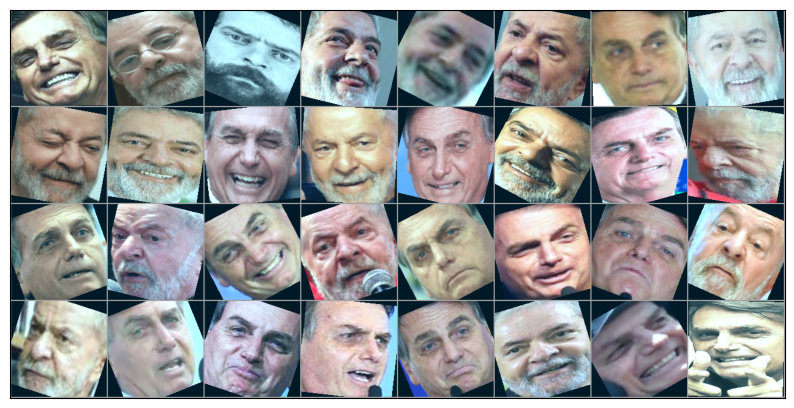

In [34]:
path = '/content/drive/MyDrive/data/bolsolula/train_cropped'

transform = transforms.Compose([transforms.Resize((160,160)),
                                transforms.RandomRotation(30),
                                transforms.RandomHorizontalFlip(),
                                transforms.ToTensor(),
                                transforms.Normalize(mean,std)
                                ])

train_dataset = datasets.ImageFolder(path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
#train_loader2 = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)

images, labels = next(iter(train_loader))
grid = torchvision.utils.make_grid(images)

show(grid, mean=mean, std=std)

print(dataset.classes[0], len(labels[labels==0]))
print(dataset.classes[1], len(labels[labels==1]))

In [36]:
path = '/content/drive/MyDrive/data/bolsolula/val_cropped'

transform = transforms.Compose([transforms.Resize((160,160)),
                                transforms.ToTensor(),
                                transforms.Normalize(mean,std)])

val_dataset = datasets.ImageFolder(path, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=len(dataset), shuffle=False)

bolsonaro 25
lula 25


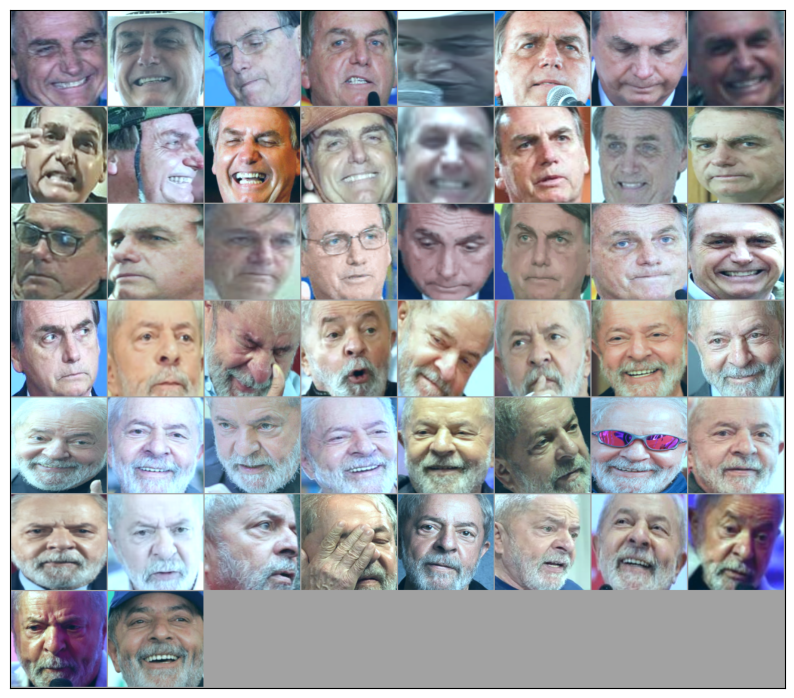

In [38]:
images, labels = next(iter(val_loader))
grid = torchvision.utils.make_grid(images)

#show(grid)
show(grid, mean=mean, std=std)

print(dataset.classes[0], len(labels[labels==0]))
print(dataset.classes[1], len(labels[labels==1]))

In [39]:
model = models.resnet18(pretrained=True)

# Fixed feature extractor
for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model.fc = nn.Linear(num_ftrs, 2)

model = model.to(device)

num_epochs=25
criterion = nn.CrossEntropyLoss()
# Observe that all parameters are being optimized
optimizer = optim.SGD(model.parameters(), lr=0.001)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s]


In [40]:
# Loop de treinamento
for epoch in range(num_epochs):
    for i, data in enumerate(train_loader):
        # obter as entradas
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)

        # Propagação para frente
        y_pred = model(inputs)

        # Calcular e imprimir o loss
        loss = criterion(y_pred, labels)

        # Backpropagation e atualização dos pesos
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    scheduler.step() # Ajusta o learning rate conforme agendamento

    with torch.no_grad():
        X_train,y_train = next(iter(train_loader2))

        y_pred = model(X_train.to(device))
        loss_train = criterion(y_pred, y_train.to(device))

        y_true = y_train.numpy()
        y_pred = np.asarray([np.argmax(x) for x in y_pred.cpu().numpy()])

        acc_train = accuracy_score(y_true, y_pred)
        f1_train = f1_score(y_true, y_pred, average=None)
        f1_train_avg = f1_score(y_true, y_pred, average='weighted')

        ######################################################################

        X_test,y_test = next(iter(val_loader))

        y_pred = model(X_test.to(device))
        loss_test = criterion(y_pred, y_test.to(device))

        y_true = y_test.numpy()
        y_pred = np.asarray([np.argmax(x) for x in y_pred.cpu().numpy()])

        acc_test = accuracy_score(y_true, y_pred)
        f1_test = f1_score(y_true, y_pred, average=None)
        f1_test_avg = f1_score(y_true, y_pred, average='weighted')

        #print(f'Epoch {epoch + 1} | lr: {scheduler.get_last_lr()[0]:.2e} | Loss (train): {loss_train:.4f} | Loss (test): {loss_test:.4f} | accuracy (train): {100*acc_train:.2f}% | accuracy (test): {100*acc_test:.2f}%')
        print(f'Epoch {epoch + 1} | lr: {scheduler.get_last_lr()[0]:.2e} | Loss (train): {loss_train:.4f} | Loss (test): {loss_test:.4f} | f1-avg (train): {100*f1_train_avg:.2f}% | f1-avg (test): {100*f1_test_avg:.2f}%')

        print(150*'*')
        df = pd.DataFrame({'Classe': [nome for nome in val_dataset.classes],
                            '%treino': 100*f1_train,
                            '%teste': 100*f1_test})
        print(df.set_index('Classe'))
        print(150*'*')

        if (epoch+1)==1:
            loss_test_best = loss_test

        if loss_test < loss_test_best:
            print('Salvando o modelo!')
            print(150*'*')
            torch.save(model.state_dict(), 'projeto.pt')
            loss_test_best = loss_test

Epoch 1 | lr: 1.00e-03 | Loss (train): 0.7860 | Loss (test): 0.7969 | f1-avg (train): 36.58% | f1-avg (test): 49.00%
******************************************************************************************************************************************************
             %treino     %teste
Classe                         
bolsonaro  65.753425  70.422535
lula        7.407407  27.586207
******************************************************************************************************************************************************
Epoch 2 | lr: 1.00e-03 | Loss (train): 0.7180 | Loss (test): 0.7283 | f1-avg (train): 39.29% | f1-avg (test): 47.62%
******************************************************************************************************************************************************
             %treino     %teste
Classe                         
bolsonaro  64.788732  68.571429
lula       13.793103  26.666667
*********************************************************

In [43]:
model = InceptionResnetV1(pretrained='vggface2', device=device, classify=True, num_classes=2)

#Freeze all layers
for param in model.parameters():
    param.requires_grad = False

#Unfreeze the last layer
for param in model.logits.parameters():
    param.requires_grad = True

model = model.to(device)

num_epochs=25
criterion = nn.CrossEntropyLoss()
# Observe that all parameters are being optimized
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [45]:
# Loop de treinamento
for epoch in range(num_epochs):
    for i, data in enumerate(train_loader):
        # obter as entradas
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)

        # Propagação para frente
        y_pred = model(inputs)

        # Calcular e imprimir o loss
        loss = criterion(y_pred, labels)

        # Backpropagation e atualização dos pesos
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    scheduler.step() # Ajusta o learning rate conforme agendamento

    with torch.no_grad():
        X_train,y_train = next(iter(train_loader2))

        y_pred = model(X_train.to(device))
        loss_train = criterion(y_pred, y_train.to(device))

        y_true = y_train.numpy()
        y_pred = np.asarray([np.argmax(x) for x in y_pred.cpu().numpy()])

        acc_train = accuracy_score(y_true, y_pred)
        f1_train = f1_score(y_true, y_pred, average=None)
        f1_train_avg = f1_score(y_true, y_pred, average='weighted')

        ######################################################################

        X_test,y_test = next(iter(val_loader))

        y_pred = model(X_test.to(device))
        loss_test = criterion(y_pred, y_test.to(device))

        y_true = y_test.numpy()
        y_pred = np.asarray([np.argmax(x) for x in y_pred.cpu().numpy()])

        acc_test = accuracy_score(y_true, y_pred)
        f1_test = f1_score(y_true, y_pred, average=None)
        f1_test_avg = f1_score(y_true, y_pred, average='weighted')

        #print(f'Epoch {epoch + 1} | lr: {scheduler.get_last_lr()[0]:.2e} | Loss (train): {loss_train:.4f} | Loss (test): {loss_test:.4f} | accuracy (train): {100*acc_train:.2f}% | accuracy (test): {100*acc_test:.2f}%')
        print(f'Epoch {epoch + 1} | lr: {scheduler.get_last_lr()[0]:.2e} | Loss (train): {loss_train:.4f} | Loss (test): {loss_test:.4f} | f1-avg (train): {100*f1_train_avg:.2f}% | f1-avg (test): {100*f1_test_avg:.2f}%')

        print(150*'*')
        df = pd.DataFrame({'Classe': [nome for nome in val_dataset.classes],
                            '%treino': 100*f1_train,
                            '%teste': 100*f1_test})
        print(df.set_index('Classe'))
        print(150*'*')

        if (epoch+1)==1:
            loss_test_best = loss_test

        if loss_test < loss_test_best:
            print('Salvando o modelo!')
            print(150*'*')
            torch.save(model.state_dict(), 'projeto.pt')
            loss_test_best = loss_test

Epoch 1 | lr: 2.50e-04 | Loss (train): 0.3623 | Loss (test): 0.0323 | f1-avg (train): 81.93% | f1-avg (test): 98.00%
******************************************************************************************************************************************************
             %treino     %teste
Classe                         
bolsonaro  83.018868  98.039216
lula       80.851064  97.959184
******************************************************************************************************************************************************
Epoch 2 | lr: 2.50e-04 | Loss (train): 0.2976 | Loss (test): 0.0347 | f1-avg (train): 81.99% | f1-avg (test): 98.00%
******************************************************************************************************************************************************
             %treino     %teste
Classe                         
bolsonaro  81.632653  98.039216
lula       82.352941  97.959184
*********************************************************

In [46]:
mtcnn = MTCNN(
    image_size=160, margin=0, min_face_size=20,
    thresholds=[0.6, 0.7, 0.7], factor=0.709, post_process=True,
    device=device
)

data_dir = '/content/drive/MyDrive/data/bolsolula/outras'

dataset = datasets.ImageFolder(data_dir, transform=transforms.Resize((512, 512)))
dataset.samples = [
    (p, p.replace(data_dir, data_dir + '_cropped'))
        for p, _ in dataset.samples
]

loader = DataLoader(
    dataset,
    batch_size=32,
    collate_fn=training.collate_pil
)

for i, (x, y) in enumerate(loader):
    mtcnn(x, save_path=y)

# Remove mtcnn to reduce GPU memory usage
del mtcnn

In [48]:
mtcnn = MTCNN(
    image_size=160, margin=0, min_face_size=20,
    thresholds=[0.6, 0.7, 0.7], factor=0.709, post_process=True,
    device=device
)

In [52]:
from PIL import Image
url = '/content/16541933526298fcc8ccfa0_1654193352_3x2_md.jpg'
img = Image.open(url)



img2 = mtcnn(img)
img2 = img2.unsqueeze(0)

model2 = model.eval()
m = nn.Softmax(dim=1)

with torch.no_grad():
  out = model2(img2.to(device))

print(m(out).squeeze(0).cpu().numpy())

idx = torch.argmax(out).item()
val_dataset.classes[idx]

[0.7316091 0.2683909]


'bolsonaro'